In [23]:
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import classification_report
from sklearn.metrics import classification_report, confusion_matrix

In [24]:
# split data into training and test sets:

# Load data
df = pd.read_csv("diabetes_binary_5050split_health_indicators_BRFSS2015.csv")

X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

In [25]:
# Initialize the Gaussian Naive Bayes model
model = GaussianNB()

# Train the model on the training data
model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = model.predict(X_test)

In [26]:
# Classification metrics table
report_dict = classification_report(
    y_test, y_pred, target_names=["No Diabetes", "Diabetes"], output_dict=True
)
metrics_df = pd.DataFrame(report_dict).transpose()
metrics_df = metrics_df[['precision', 'recall', 'f1-score', 'support']]
metrics_df = metrics_df
metrics_df.index = ["No Diabetes", "Diabetes", "Accuracy", "Macro Avg", "Weighted Avg"]


display(metrics_df.style.set_caption("Naive-Bayes Classification Metrics").set_table_styles(
    [{'selector': 'th', 'props': [('text-align', 'center')]},
     {'selector': 'td', 'props': [('text-align', 'center')]}]
))

,precision,recall,f1-score,support
No Diabetes,0.716237,0.724824,0.720505,7090.000000
Diabetes,0.719845,0.711165,0.715478,7049.000000
Accuracy,0.718014,0.718014,0.718014,0.718014
Macro Avg,0.718041,0.717994,0.717992,14139.000000
Weighted Avg,0.718036,0.718014,0.717999,14139.000000


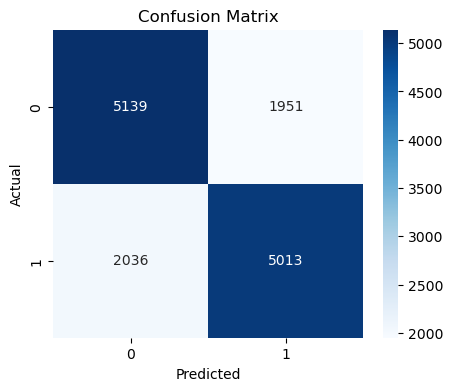

In [27]:
# Evaluate model:

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)


plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [28]:
# another graph